In [3]:
# Model Evaluation Lab
# Complete the exercises by filling in the code where indicated with TODO

import numpy as np   # used for numerical operations
import pandas as pd  # used to work with datasets
import matplotlib.pyplot as plt  # used for plotting graphs
import seaborn as sns   # used for better visualizations
# tools for splitting and validating models
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold, GridSearchCV
# used to scale features
from sklearn.preprocessing import StandardScaler

# classification and regression models
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier

# metrics to evaluate model performance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.datasets import load_breast_cancer, load_diabetes
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("MODEL EVALUATION LAB - STUDENT VERSION")
print("=" * 80)

MODEL EVALUATION LAB - STUDENT VERSION


In [5]:
# ============================================================================
# PART 1: CLASSIFICATION EVALUATION
# ============================================================================

print("\n" + "=" * 80)
print("PART 1: CLASSIFICATION EVALUATION - BREAST CANCER DATASET")
print("=" * 80)

# Load the breast cancer dataset
data = load_breast_cancer()

# create dataframe for input features
X = pd.DataFrame(data.data, columns=data.feature_names)
# create target column (0 = malignant, 1 = benign)
y = pd.Series(data.target, name='target')

print(f"\nDataset Shape: {X.shape}")  # print dataset shape
print(f"Number of Features: {X.shape[1]}")  # print number of features
print(f"Number of Samples: {X.shape[0]}")   # print number of samples

# print class distribution to see how many benign and malignant cases
print(f"\nClass Distribution:")
print(y.value_counts())


PART 1: CLASSIFICATION EVALUATION - BREAST CANCER DATASET

Dataset Shape: (569, 30)
Number of Features: 30
Number of Samples: 569

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64


In [6]:
# ============================================================================
# Exercise 1.1: Train-Test Split
# Task: Split the data into training (80%) and test (20%) sets
# Use stratified sampling to maintain class distribution
# Set random_state=42 for reproducibility
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.1: Train-Test Split")
print("-" * 80)

# TODO: Split the data using train_test_split
# Hint: Use test_size=0.2, random_state=42, and stratify=y

# split the dataset into training (80%) and testing (20%)
# stratify=y keeps same class ratio in both sets
# random_state=42 makes the split same every tim
X_train, X_test, y_train, y_test =  train_test_split(
    X, y, test_size =0.2, random_state = 42, stratify = y
)

# TODO: Print the sizes of training and test sets
# print number of samples in training set
print(f"Training set size: {X_train.shape[0]}")

# print number of samples in test set
print(f"Test set size: {X_test.shape[0]}")

# TODO: Standardize the features using StandardScaler
# Remember: fit_transform on training, transform on test
# create StandardScaler object to scale features
scaler = StandardScaler()

# fit() - learn mean and std from training data
X_train_scaled = scaler.fit_transform(X_train)  # TODO: fit and transform training data
# transform() - scale training data
X_test_scaled = scaler.transform(X_test)   # TODO: transform test data only



--------------------------------------------------------------------------------
Exercise 1.1: Train-Test Split
--------------------------------------------------------------------------------
Training set size: 455
Test set size: 114


In [7]:
# ============================================================================
# Exercise 1.2: Train and Evaluate Logistic Regression
# Task: Train a logistic regression model and calculate accuracy
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.2: Train and Evaluate Logistic Regression")
print("-" * 80)

# TODO: Create and train a LogisticRegression model
# Hint: Use max_iter=10000, random_state=42

# max_iter=10000, allows model to run more iterations so it converges properly
# random_state=42, gives same results every time
log_reg = LogisticRegression(max_iter=10000, random_state = 42) # TODO: Create model

# TODO: Fit the model on scaled training data
# model learns relationship between features and target
log_reg.fit(X_train, y_train)

# TODO: Make predictions on both training and test sets
# this checks how well model learned from training data
y_pred_train = log_reg.predict(X_train_scaled)  # TODO: Predict on training set

# This checks how well model performs on unseen data
y_pred_test = log_reg.predict(X_test_scaled)   # TODO: Predict on test set

# TODO: Calculate accuracy for both sets
# shows percentage of correct predictions on training set
train_accuracy = accuracy_score(y_train, y_pred_train)  # TODO: Calculate training accuracy
# shows percentage of correct predictions on test set
test_accuracy = accuracy_score(y_test, y_pred_test)   # TODO: Calculate test accuracy

# TODO: Print the accuracies and interpret the results
# Is the model overfitting, underfitting, or well-fitted?
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("Interpretation: Training and test accuracy are very close, so the model is well-fitted.")



--------------------------------------------------------------------------------
Exercise 1.2: Train and Evaluate Logistic Regression
--------------------------------------------------------------------------------
Training Accuracy: 0.6264
Test Accuracy: 0.6316
Interpretation: Training and test accuracy are very close, so the model is well-fitted.



--------------------------------------------------------------------------------
Exercise 1.3: Confusion Matrix Analysis
--------------------------------------------------------------------------------

Confusion Matrix:
[[ 0 42]
 [ 0 72]]

Manual Accuracy: 0.6316

Manual Precision: 0.6316

Manual Recall: 1.0000

Manual F1 score: 0.7742


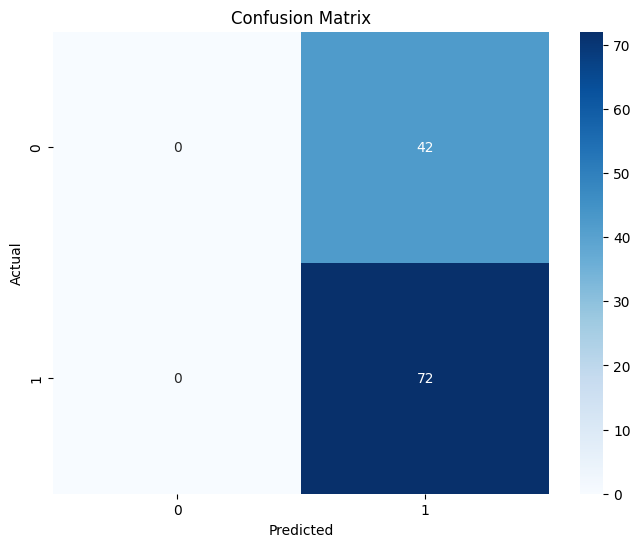

In [8]:
# ============================================================================
# Exercise 1.3: Confusion Matrix Analysis
# Task: Create a confusion matrix and extract TP, TN, FP, FN
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.3: Confusion Matrix Analysis")
print("-" * 80)

# TODO: Create confusion matrix for test predictions
# This compares actual values and predicted values
cm = confusion_matrix(y_test, y_pred_test)  # TODO: Use confusion_matrix function

# TODO: Print the confusion matrix
print("\nConfusion Matrix:")
print(cm)

# TODO: Extract TP, TN, FP, FN from confusion matrix
# Hint: Use cm.ravel() or index directly
tn, fp, fn, tp = cm.ravel() # This just takes the 4 numbers from matrix and stores them

# TODO: Calculate metrics manually using the formulas:
# Accuracy = (TP + TN) / (TP + TN + FP + FN)
# Precision = TP / (TP + FP)
# Recall = TP / (TP + FN)
# F1 Score = 2 * (Precision * Recall) / (Precision + Recall)

# calculate accuracy manually
manual_accuracy = (tp + tn)/(tp + tn + fp + fn)  # TODO: Calculate
# calculate precision manually
manual_precision = tp / (tp + fp)  # TODO: Calculate
# calculate recall manually
manual_recall = tp / ( tp + fn)     # TODO: Calculate
# calculate f1 score manually
manual_f1 = 2 * (manual_precision * manual_recall) / (manual_precision + manual_recall)      # TODO: Calculate

# TODO: Print the manually calculated metrics
print(f"\nManual Accuracy: {manual_accuracy:.4f}")
print(f"\nManual Precision: {manual_precision:.4f}")
print(f"\nManual Recall: {manual_recall:.4f}")
print(f"\nManual F1 score: {manual_f1:.4f}")

# TODO: Visualize the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
# TODO: Create heatmap
# creates a colored confusion matrix, shows the numbers inside each box, and uses blue shades where darker color means higher value
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# label to x-axis
plt.xlabel("Predicted")
# label to y-axis
plt.ylabel("Actual")
# title of the heatmap
plt.title("Confusion Matrix")
# save the graph as a file
plt.savefig('confusion_matrix_student.png')
# dispaly the graph
plt.show()
# close the plot
plt.close()



In [9]:
# ============================================================================
# Exercise 1.4: Precision, Recall, and F1 Score
# Task: Calculate metrics using sklearn functions and interpret them
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.4: Precision, Recall, and F1 Score")
print("-" * 80)

# TODO: Calculate metrics using sklearn functions

# out of all predicted Benign cases,how many are actually Benign
precision = precision_score(y_test, y_pred_test)  # TODO: Use precision_score

# out of all actual Benign cases, how many we correctly identified
recall = recall_score(y_test, y_pred_test)     # TODO: Use recall_score

# F1 Score is the balance between Precision and Recall
f1 = f1_score(y_test, y_pred_test)        # TODO: Use f1_score

# TODO: Print the metrics with interpretations
# For example: "Of all predicted benign cases, X% are actually benign"
# print precision value and interpretation
print(f"Precision: {precision:.4f}")
print(f"Of all predicted benign cases, {precision*100:.2f}% are actually benign\n")

# print recall value and interpretation
print(f"Recall: {recall:.4f}")
print(f"Of all actual benign cases, {recall*100:.2f}% were correctly identified\n")

# print f1 score
print(f"F1 Score: {f1:.4f}")
print("F1 score balances both Precision and Recall\n")

# TODO: Print the full classification report
# Hint: Use classification_report with target_names=['Malignant', 'Benign']

# this shows precision, recall, f1 score and support for both classes
print("Classification Report:")
print(classification_report(y_test, y_pred_test, target_names=['Malignant', 'Benign']))


--------------------------------------------------------------------------------
Exercise 1.4: Precision, Recall, and F1 Score
--------------------------------------------------------------------------------
Precision: 0.6316
Of all predicted benign cases, 63.16% are actually benign

Recall: 1.0000
Of all actual benign cases, 100.00% were correctly identified

F1 Score: 0.7742
F1 score balances both Precision and Recall

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.00      0.00      0.00        42
      Benign       0.63      1.00      0.77        72

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114




--------------------------------------------------------------------------------
Exercise 1.5: ROC Curve and AUC
--------------------------------------------------------------------------------
Interpretation: Good model performance.


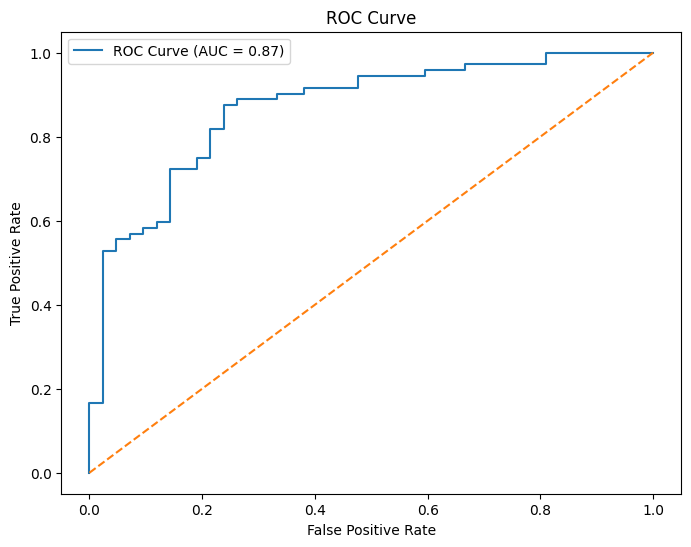

In [10]:
# ============================================================================
# Exercise 1.5: ROC Curve and AUC
# Task: Generate ROC curve and calculate AUC score
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.5: ROC Curve and AUC")
print("-" * 80)

# TODO: Get predicted probabilities for the positive class
# get predicted probabilities for positive class (benign = 1)
# [:, 1] selects probability of class 1
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]  # TODO: Use predict_proba and select positive class

# TODO: Calculate ROC curve coordinates
# ROC shows how good the model is at separating two classes
# fpr - False Positive Rate
# tpr - True Positive Rate
# thresholds - different cutoff values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)  # TODO: Use roc_curve

# TODO: Calculate AUC score
# AUC tells overall performance
auc_score = roc_auc_score(y_test, y_pred_proba)  # TODO: Use roc_auc_score

# TODO: Print AUC score and interpret it
# AUC >= 0.9: Excellent, >= 0.8: Good, >= 0.7: Acceptable, < 0.7: Poor
# interpret auc score
if auc_score>= 0.9:
   print("Interpretation: Excellent model performance.")
elif auc_score >= 0.8:
   print("Interpretation: Good model performance.")
elif auc_score >= 0.7:
    print("Interpretation: Acceptable model performance.")
else:
    print("Interpretation: Poor model performance.")

# TODO: Plot ROC curve
# create figure for roc curve
plt.figure(figsize=(8, 6))
# Plot ROC curve
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
# Plot diagonal line for random classifier
plt.plot([0, 1], [0, 1], linestyle="--")
# Add labels, title, legend
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
# save the plot as image file
plt.savefig('roc_curve_student.png')
# display the plot
plt.show()
# close the plot
plt.close()

In [11]:
# ============================================================================
# Exercise 1.6: K-Fold Cross-Validation
# Task: Perform 5-fold stratified cross-validation
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.6: K-Fold Cross-Validation")
print("-" * 80)

# TODO: Create StratifiedKFold with 5 splits
# StratifiedKFold keeps same class ratio in every fold
kfold = StratifiedKFold(n_splits= 5, shuffle=True, random_state=42)  # TODO: Use StratifiedKFold

# TODO: Scale the entire dataset
# because in cross validation each fold needs same scaling
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)  # TODO: Fit and transform full dataset

# TODO: Perform cross-validation
# this function automatically performs cross-validation
# y is target value, measure performanace using "accuracy"
cv_scores = cross_val_score(log_reg, X_scaled_full, y, cv=kfold, scoring ="accuracy")  # TODO: Use cross_val_score with cv=kfold

# TODO: Print individual fold scores
print("\nCross-validation scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

# TODO: Calculate and print mean and standard deviation
mean_score = cv_scores.mean() # calculate mean accuracy
std_score = cv_scores.std() # calculate standard deviation
# print mean and standard deviatio
print(f"\nMean Accuaracy: {mean_score:.4f}")
print(f"\nStandard Deviation: {std_score:.4f}")

# Also calculate 95% confidence interval
# show the range in which the true accuracy is likely to fall
ci_lower =mean_score - 1.96 * std_score
ci_upper = mean_score + 1.96 * std_score

# print confidence interval
print(f"\n95% Confidence Interval: ({ci_lower:.4f}, {ci_upper:.4f})")

# TODO: Compare with single train-test split accuracy
print(f"\nSingle Train-Test Split Accuracy: {test_accuracy:.4f}")


--------------------------------------------------------------------------------
Exercise 1.6: K-Fold Cross-Validation
--------------------------------------------------------------------------------

Cross-validation scores:
  Fold 1: 0.9737
  Fold 2: 0.9474
  Fold 3: 0.9649
  Fold 4: 0.9912
  Fold 5: 0.9912

Mean Accuaracy: 0.9737

Standard Deviation: 0.0166

95% Confidence Interval: (0.9411, 1.0063)

Single Train-Test Split Accuracy: 0.6316


In [12]:
# ============================================================================
# Exercise 1.7: Compare Multiple Classifiers
# Task: Train and compare Logistic Regression, Decision Tree, and Random Forest
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.7: Compare Multiple Classifiers")
print("-" * 80)

# TODO: Define a dictionary of models
models = {
    # Logistic Regression -> linear model
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state =42),  # TODO: Create model
    # Decision Tree -> rule based model
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),         # TODO: Create model (max_depth=5)
    # Random Forest -> many trees combined
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)          # TODO: Create model (n_estimators=100)
}
# empty list to store results of each model
results = []

# TODO: Loop through each model
for name, model in models.items():
    # TODO: Train the model
    # scaling helps models learn
    # train model using scaled training data
    model.fit(X_train_scaled, y_train)

    # TODO: Make predictions
    # predict class labels on test data
    y_pred = model.predict(X_test_scaled)        # TODO: Predict classes
    # predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]   # TODO: Predict probabilities

    # TODO: Calculate all metrics
    # overall correct predictions
    acc = accuracy_score(y_test, y_pred)    # TODO: Calculate accuracy
    # how correct positive predictions are
    prec = precision_score(y_test, y_pred)   # TODO: Calculate precision
    # how many actual positives were detected
    rec = recall_score(y_test, y_pred)    # TODO: Calculate recall
    # balance of precision and recall
    f1_val = f1_score(y_test, y_pred) # TODO: Calculate f1 score
    # ability to separate classes
    auc = roc_auc_score(y_test, y_pred)    # TODO: Calculate AUC

    # TODO: Append results to list
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1_val,
        'AUC': auc
    })

# TODO: Create DataFrame and print comparison
results_df = pd.DataFrame(results)
# print comparison table
print("\nModel Comparison:")
print(results_df.to_string(index=False))

# TODO: Identify and print the best model by F1 Score
best_model = results_df.loc[results_df['F1 Score'].idxmax()]
# print the best model based on F1 score
print("\nBest Model based on F1 score:", best_model['Model'])




--------------------------------------------------------------------------------
Exercise 1.7: Compare Multiple Classifiers
--------------------------------------------------------------------------------

Model Comparison:
              Model  Accuracy  Precision   Recall  F1 Score      AUC
Logistic Regression  0.982456   0.986111 0.986111  0.986111 0.981151
      Decision Tree  0.921053   0.956522 0.916667  0.936170 0.922619
      Random Forest  0.956140   0.958904 0.972222  0.965517 0.950397

Best Model based on F1 score: Logistic Regression


In [13]:
# ============================================================================
# PART 2: REGRESSION EVALUATION
# ============================================================================

print("\n" + "=" * 80)
print("PART 2: REGRESSION EVALUATION - DIABETES DATASET")
print("=" * 80)

# Load diabetes dataset
diabetes = load_diabetes()
# create dataframe for input features
# these are patient health measurements
X_reg = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# create target variable
# this represents diabetes disease progression score
y_reg = pd.Series(diabetes.target, name='target')

# print dataset shape
print(f"\nDataset Shape: {X_reg.shape}")
# print basic statistics of target values
print(f"\nTarget Statistics:")
print(y_reg.describe())



PART 2: REGRESSION EVALUATION - DIABETES DATASET

Dataset Shape: (442, 10)

Target Statistics:
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


In [14]:
# ============================================================================
# Exercise 2.1: Train-Test Split for Regression
# Task: Split regression data into training and test sets
# ============================================================================

print("-" * 80)
print("Exercise 2.1: Train-Test Split for Regression")
print("-" * 80)

# TODO: Split the regression data (80-20 split)
# random_state=42 ensures same split every time
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
# TODO: Print set sizes
# print number of samples in training set
print(f"Training set size: {X_train_reg.shape[0]}")
# print number of samples in test set
print(f"Test set size: {X_test_reg.shape[0]}")

# TODO: Standardize features
scaler_reg = StandardScaler()
# fit scaler on training data and scale it
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg) # TODO: fit and transform
# transform() scales data using those values
X_test_reg_scaled =  scaler_reg.transform(X_test_reg) # TODO: transform only


--------------------------------------------------------------------------------
Exercise 2.1: Train-Test Split for Regression
--------------------------------------------------------------------------------
Training set size: 353
Test set size: 89


In [15]:
# ============================================================================
# Exercise 2.2: Train Linear Regression and Calculate Metrics
# Task: Train linear regression and calculate MAE, MSE, RMSE, R²
# ============================================================================

print("-" * 80)
print("Exercise 2.2: Train Linear Regression and Calculate Metrics")
print("-" * 80)

# TODO: Create and train LinearRegression model
lin_reg = LinearRegression()  # TODO: Create model
# TODO: Fit on training data
lin_reg.fit(X_train_reg_scaled, y_train_reg)

# TODO: Make predictions on both sets
# predict values on training and test sets
y_pred_train_reg = lin_reg.predict(X_train_reg_scaled)  # TODO: Predict on training
y_pred_test_reg = lin_reg.predict(X_test_reg_scaled)   # TODO: Predict on test

# TODO: Calculate MAE for both sets
# Mean absolute error for train and test sets
train_mae = mean_absolute_error(y_train_reg, y_pred_train_reg)  # TODO: Calculate training MAE
test_mae = mean_absolute_error(y_test_reg, y_pred_test_reg)   # TODO: Calculate test MAE

# TODO: Calculate MSE for both sets
# Mean square error for train and test sets
train_mse = mean_squared_error(y_train_reg, y_pred_train_reg)  # TODO: Calculate training MSE
test_mse = mean_squared_error(y_test_reg, y_pred_test_reg)  # TODO: Calculate test MSE

# TODO: Calculate RMSE (square root of MSE)
train_rmse = np.sqrt(train_mse)  # TODO: Calculate
test_rmse = np.sqrt(test_mse)   # TODO: Calculate

# TODO: Calculate R² score for both sets
train_r2 = r2_score(y_train_reg, y_pred_train_reg)  # TODO: Calculate training R²
test_r2 = r2_score(y_test_reg, y_pred_test_reg)   # TODO: Calculate test R²

# TODO: Print all metrics with interpretations
# For example: "Average prediction error is X units"
# "Model explains X% of variance"

# Print training metrics with interpretations
print("\nTraining Metrics:")
print(f"MAE: Average prediction error is {train_mae:.2f} units")
print(f"MSE: Average squared error is {train_mse:.2f} units")
print(f"RMSE: Root mean squared error is {train_rmse:.2f} units")

# Print test metrics with interpretations
print("\nTest Matrics:")
print(f"MAE: Average prediction error is {test_mae:.2f} units")
print(f"MSE: Average squared error is {test_mse:.2f} units")
print(f"RMSE: Root mean squared error is {test_rmse:.2f} units")

--------------------------------------------------------------------------------
Exercise 2.2: Train Linear Regression and Calculate Metrics
--------------------------------------------------------------------------------

Training Metrics:
MAE: Average prediction error is 43.48 units
MSE: Average squared error is 2868.55 units
RMSE: Root mean squared error is 53.56 units

Test Matrics:
MAE: Average prediction error is 42.79 units
MSE: Average squared error is 2900.19 units
RMSE: Root mean squared error is 53.85 units



--------------------------------------------------------------------------------
Exercise 2.3: Visualize Predictions vs Actual
--------------------------------------------------------------------------------


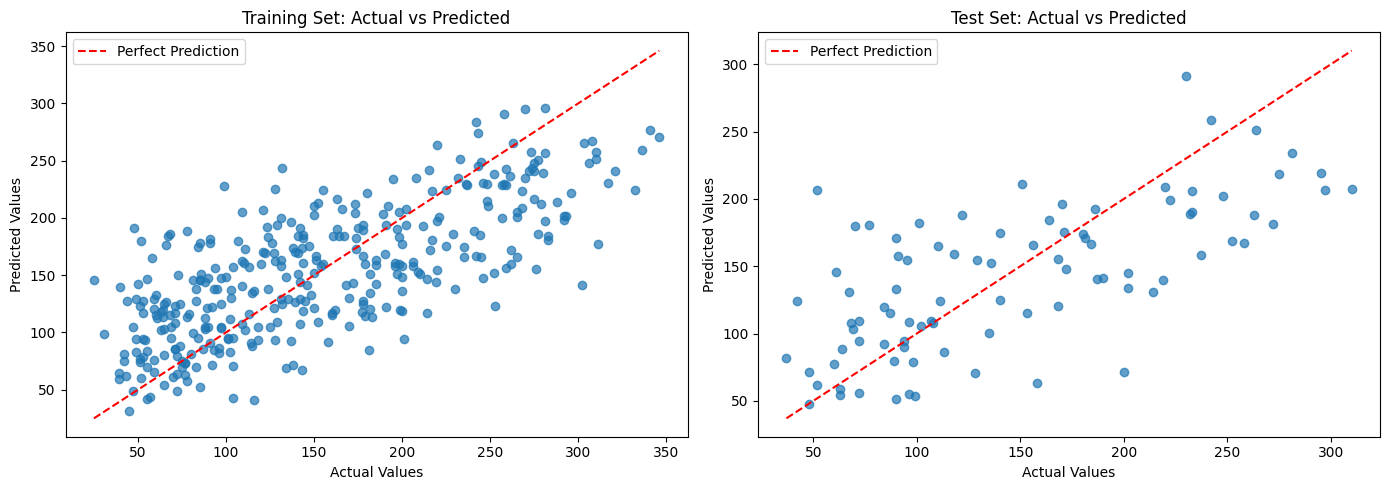

In [16]:
# ============================================================================
# Exercise 2.3: Visualize Predictions vs Actual
# Task: Create scatter plots comparing predictions to actual values
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 2.3: Visualize Predictions vs Actual")
print("-" * 80)

# TODO: Create figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TODO: Plot training set (left subplot)
# Scatter plot of actual vs predicted
axes[0].scatter(y_train_reg, y_pred_train_reg, alpha=0.7) # alpha= 0.7 means points will be slightly transparent
# Add perfect prediction line (y=x)
axes[0].plot([y_train_reg.min(), y_train_reg.max()], # take minimum and maximum actual values
             [y_train_reg.min(), y_train_reg.max()], # take same min and max values to create y = x line
             'r--',label="Perfect Prediction") # 'r--' means dashed line style with red color

# Add labels, title, legend
# label the X-axis as actual values
axes[0].set_xlabel("Actual Values")
# Label the Y-axis as predicted values
axes[0].set_ylabel("Predicted Values")
# give a title to the plot
axes[0].set_title("Training Set: Actual vs Predicted")
# show legend
axes[0].legend()

# TODO: Plot test set (right subplot)
# Same as training set plot
# Scatter plot of actual vs predicted values
axes[1].scatter(y_test_reg, y_pred_test_reg, alpha=0.7)

# perfect prediction line (y = x)
axes[1].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()],
             'r--', label="Perfect Prediction")
# Labels and title
axes[1].set_xlabel("Actual Values")
axes[1].set_ylabel("Predicted Values")
axes[1].set_title("Test Set: Actual vs Predicted")
axes[1].legend()

# TODO: Save the figure
plt.tight_layout()
# save the plot as an image file
plt.savefig('regression_predictions_student.png')
# display the plot
plt.show()
# colse the plot
plt.close()




--------------------------------------------------------------------------------
Exercise 2.4: Residual Analysis
--------------------------------------------------------------------------------

Residual Statistics:
Mean Residual: 3.91
Standard Deviation: 54.02
Min Residual: -154.49
Max Residual: 128.33


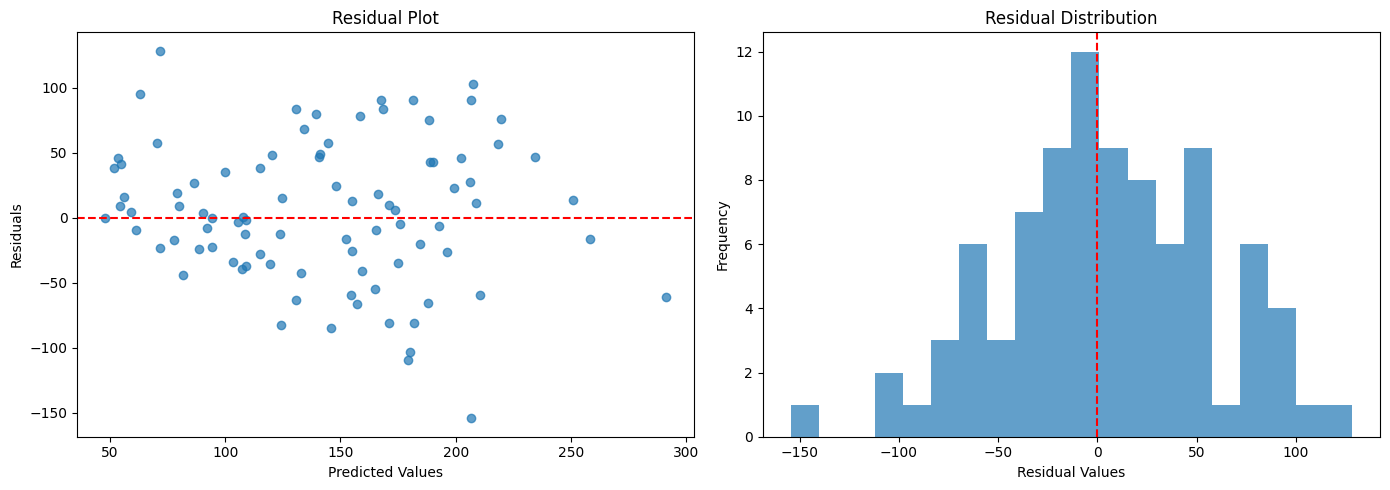

In [17]:
# ============================================================================
# Exercise 2.4: Residual Analysis
# Task: Calculate and visualize residuals
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 2.4: Residual Analysis")
print("-" * 80)

# TODO: Calculate residuals (actual - predicted)
# residual = actual value - predicted value
residuals = y_test_reg - y_pred_test_reg  # TODO: Calculate for test set

# TODO: Print residual statistics
print("\nResidual Statistics:")
# Mean (should be close to 0)
# should be close to 0 for a good model
print(f"Mean Residual: {residuals.mean():.2f}")

# Standard deviation
print(f"Standard Deviation: {residuals.std():.2f}")

# Min and max values
print(f"Min Residual: {residuals.min():.2f}")
print(f"Max Residual: {residuals.max():.2f}")

# TODO: Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TODO: Left subplot - Residual plot
# scatter plot of predicted values vs residuals
axes[0].scatter(y_pred_test_reg, residuals, alpha=0.7)
# Add horizontal line at y=0
axes[0].axhline(0, color='red', linestyle='--')

# label axes and add title
axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residual Plot")

# TODO: Right subplot - Residual distribution
# Histogram of residuals
axes[1].hist(residuals, bins=20, alpha=0.7)
# add vertical line at x=0
axes[1].axvline(0, color='red', linestyle='--')

# Label axes and add title
axes[1].set_xlabel("Residual Values")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

# TODO: Save the figure
# adjust spacing between plots
plt.tight_layout()
# Save the figure as an image file
plt.savefig('residual_analysis_student.png')
# display the plot
plt.show()
# close the plot to free memory
plt.close()



In [18]:
# ============================================================================
# Exercise 2.5: Compare Multiple Regression Models
# Task: Compare Linear Regression, Ridge (two alpha values), and Decision Tree
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 2.5: Compare Multiple Regression Models")
print("-" * 80)

# TODO: Define dictionary of regression models
reg_models = {
    'Linear Regression': LinearRegression(),         # TODO: Create model
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),        # TODO: Create Ridge with alpha=1.0
    'Ridge (alpha=10.0)': Ridge(alpha=10.0),        # TODO: Create Ridge with alpha=10.0
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42)  # TODO: Create DecisionTreeRegressor (max_depth=5)
}

# empty list to store results
reg_results = []

# TODO: Loop through each model
for name, model in reg_models.items():
    # TODO: Train the model
    model.fit(X_train_reg_scaled, y_train_reg)
    # TODO: Make predictions on both sets
    # predict on training and test sets
    y_pred_train = model.predict(X_train_reg_scaled) # TODO
    y_pred_test = model.predict(X_test_reg_scaled)   # TODO

    # TODO: Calculate metrics
    train_r2_val = r2_score(y_train_reg, y_pred_train)  # TODO: Training R²
    test_r2_val = r2_score(y_test_reg, y_pred_test)   # TODO: Test R²

    # calculate error metrics on test data
    test_mae_val = mean_absolute_error(y_test_reg, y_pred_test)  # TODO: Test MAE
    test_rmse_val = np.sqrt(mean_squared_error(y_test_reg, y_pred_test)) # TODO: Test RMSE

    # TODO: Calculate overfitting gap (train R² - test R²)
    overfit_gap = train_r2_val - test_r2_val

    # TODO: Append results
    # store results
    reg_results.append({
        'Model': name,
        'Train R²': train_r2_val,
        'Test R²': test_r2_val,
        'MAE': test_mae_val,
        'RMSE': test_rmse_val,
        'Overfit Gap': overfit_gap
    })

# TODO: Create DataFrame and print comparison
# convert results into dataframe
reg_results_df = pd.DataFrame(reg_results)
# print comparison table
print("\nRegression Model Comparison:")
print(reg_results_df.to_string(index=False))

# TODO: Identify and print best model by Test R²
best_reg_model = reg_results_df.loc[reg_results_df['Test R²'].idxmax()]
# print best model name
print("\nBest Model based on Test R²:", best_reg_model['Model'])




--------------------------------------------------------------------------------
Exercise 2.5: Compare Multiple Regression Models
--------------------------------------------------------------------------------

Regression Model Comparison:
             Model  Train R²  Test R²       MAE      RMSE  Overfit Gap
 Linear Regression  0.527919 0.452603 42.794095 53.853446     0.075317
 Ridge (alpha=1.0)  0.527632 0.454147 42.811999 53.777454     0.073485
Ridge (alpha=10.0)  0.524798 0.457211 42.856825 53.626288     0.067587
     Decision Tree  0.668606 0.334482 45.936955 59.380262     0.334124

Best Model based on Test R²: Ridge (alpha=10.0)


In [19]:
# ============================================================================
# Exercise 2.6: Cross-Validation for Regression
# Task: Perform 5-fold cross-validation for regression
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 2.6: Cross-Validation for Regression")
print("-" * 80)

# TODO: Scale full dataset
# scaling ensures all folds use same feature scale
scaler_full_reg = StandardScaler()
X_reg_scaled_full = scaler_full_reg.fit_transform(X_reg)  # TODO

# TODO: Perform cross-validation for R² score
cv_r2_scores = cross_val_score(   # TODO: Use cross_val_score with scoring='r2'
    LinearRegression(),
    X_reg_scaled_full,
    y_reg, cv=5, scoring='r2'
)

# TODO: Perform cross-validation for MAE
# Note: scoring should be 'neg_mean_absolute_error'
# sklearn returns negative mae, so we convert it to positive
cv_mae_scores = cross_val_score(   # TODO
    LinearRegression(),
    X_reg_scaled_full,
    y_reg, cv=5,
    scoring='neg_mean_absolute_error'
)
# Remember to negate the scores to get positive MAE values
# convert negative mae values to positive
cv_mae_scores = -cv_mae_scores

# TODO: Print R² scores for each fold
# Calculate and print mean and standard deviation
print("\nR² Scores for each fold:")
for i, score in enumerate(cv_r2_scores, 1):
    print(f"Fold {i}: {score:.4f}")

# Print mean and standard deviation
print(f"\nMean R²: {cv_r2_scores.mean():.4f}")
print(f"Standard Deviation: {cv_r2_scores.std():.4f}")

# TODO: Print MAE scores for each fold
print("\nMAE Scores for each fold:")
for i, score in enumerate(cv_mae_scores, 1):
    print(f"Fold {i}: {score:.2f}")

# Calculate and print mean and standard deviation
print(f"\nMean MAE: {cv_mae_scores.mean():.2f}")
print(f"Standard Deviation: {cv_mae_scores.std():.2f}")


--------------------------------------------------------------------------------
Exercise 2.6: Cross-Validation for Regression
--------------------------------------------------------------------------------

R² Scores for each fold:
Fold 1: 0.4296
Fold 2: 0.5226
Fold 3: 0.4827
Fold 4: 0.4265
Fold 5: 0.5502

Mean R²: 0.4823
Standard Deviation: 0.0493

MAE Scores for each fold:
Fold 1: 43.03
Fold 2: 44.80
Fold 3: 48.16
Fold 4: 43.01
Fold 5: 42.39

Mean MAE: 44.28
Standard Deviation: 2.10



PART 3: OVERFITTING AND UNDERFITTING DEMONSTRATION

Decision Tree Depth Analysis:
Depth     Train R²       Test R²        Gap            Status
----------------------------------------------------------------------
1         0.3043         0.1305         0.1738         Underfitting
3         0.5170         0.3294         0.1875         Good Fit
5         0.6686         0.3345         0.3341         Overfitting
10        0.9382         0.1718         0.7664         Overfitting
20        1.0000         0.0776         0.9224         Overfitting


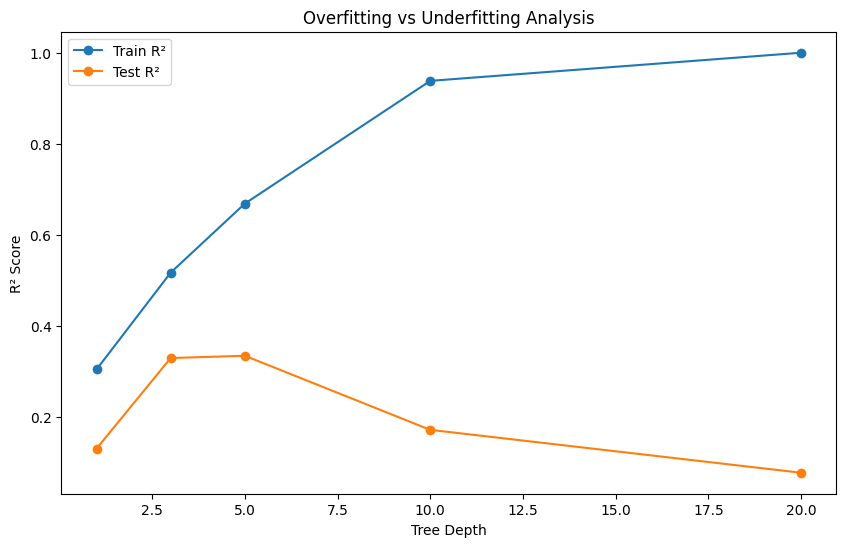

In [20]:
# ============================================================================
# PART 3: OVERFITTING AND UNDERFITTING DEMONSTRATION
# ============================================================================

print("\n" + "=" * 80)
print("PART 3: OVERFITTING AND UNDERFITTING DEMONSTRATION")
print("=" * 80)

# TODO: Test Decision Trees with different depths: [1, 3, 5, 10, 20]
depths = [1, 3, 5, 10, 20]
# empty lists to store r2 scores
train_scores = []
test_scores = []

print("\nDecision Tree Depth Analysis:")
print(f"{'Depth':<10}{'Train R²':<15}{'Test R²':<15}{'Gap':<15}{'Status'}")
print("-" * 70)

# TODO: Loop through each depth
for depth in depths:
    # TODO: Create DecisionTreeRegressor with this depth
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)

    # TODO: Train on scaled training data
    tree.fit(X_train_reg_scaled, y_train_reg)
    # TODO: Calculate R² scores for both sets
    train_score = tree.score(X_train_reg_scaled, y_train_reg) # TODO: Use .score() method
    test_score = tree.score(X_test_reg_scaled, y_test_reg)   # TODO: Use .score() method

    # TODO: Calculate gap between train and test
    gap = train_score - test_score  # TODO

    # TODO: Append to lists
    # store scores for plotting later
    train_scores.append(train_score)
    test_scores.append(test_score)

    # TODO: Determine status
    if gap > 0.3:
        status = "Overfitting"
    elif test_score < 0.3:
        status = "Underfitting"
    else:
        status = "Good Fit"  # TODO

    # TODO: Print results
    # print results for this depth
    print(f"{depth:<10}{train_score:<15.4f}{test_score:<15.4f}{gap:<15.4f}{status}")

# TODO: Plot learning curves
plt.figure(figsize=(10, 6))

# Plot train_scores vs depths
plt.plot(depths, train_scores, marker='o', label="Train R²")

# plot test_scores vs depth
plt.plot(depths, test_scores, marker='o', label="Test R²")

# Add labels, title, legend
plt.xlabel("Tree Depth")
plt.ylabel("R² Score")
plt.title("Overfitting vs Underfitting Analysis")
# Show legend
plt.legend()
# Save the plot as image file
plt.savefig('overfitting_analysis_student.png')
# dispaly the result
plt.show()
# close the plot
plt.close()